# AML, ALL, and PBMC

In [11]:
import os

import numpy as np
import pandas as pd

import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

import matplotlib as mpl

from matplotlib import font_manager
from matplotlib.colors import ListedColormap


In [ ]:
# Project paths

project_dir = 'D:/Projects/ehlastic_release'
data_dir = os.path.join(project_dir, 'data')
fig_dir = os.path.join(project_dir, 'figure', 'Fig_AML_ALL_PBMC')
os.makedirs(fig_dir, exist_ok=True)

# Data

df_val = pd.read_excel(os.path.join(data_dir, 'Max_Gerry', 'Max_Tested_Peptides_CellReports.xlsx'), sheet_name="AML_ALL_PBMC")

peptide_sample_groups = df_val.groupby('peptide')['sample_group'].agg(lambda values: set(values))

cancer_only_sequences = {
    peptide
    for peptide, groups in peptide_sample_groups.items()
    if 'Cancer samples' in groups and 'Non-cancer samples' not in groups
}

non_cancer_sample_type = 'Non-cancer PBMC and BM, PXD038782'
cancer_sample_types = [
    'LSC, PXD038691',
    'AML, PXD038691',
    'B-ALL',
]
heatmap_panel_order = [
    non_cancer_sample_type,
    *cancer_sample_types,
]

peptide_group_order = ['signal_peptide', 'other_canonical', 'noncanonical']
peptide_group_labels = {
    'signal_peptide': 'Signal Peptide',
    'other_canonical': 'Other Canonical',
    'noncanonical': 'Noncanonical',
}
peptide_group_rank = {group_name: idx for idx, group_name in enumerate(peptide_group_order)}



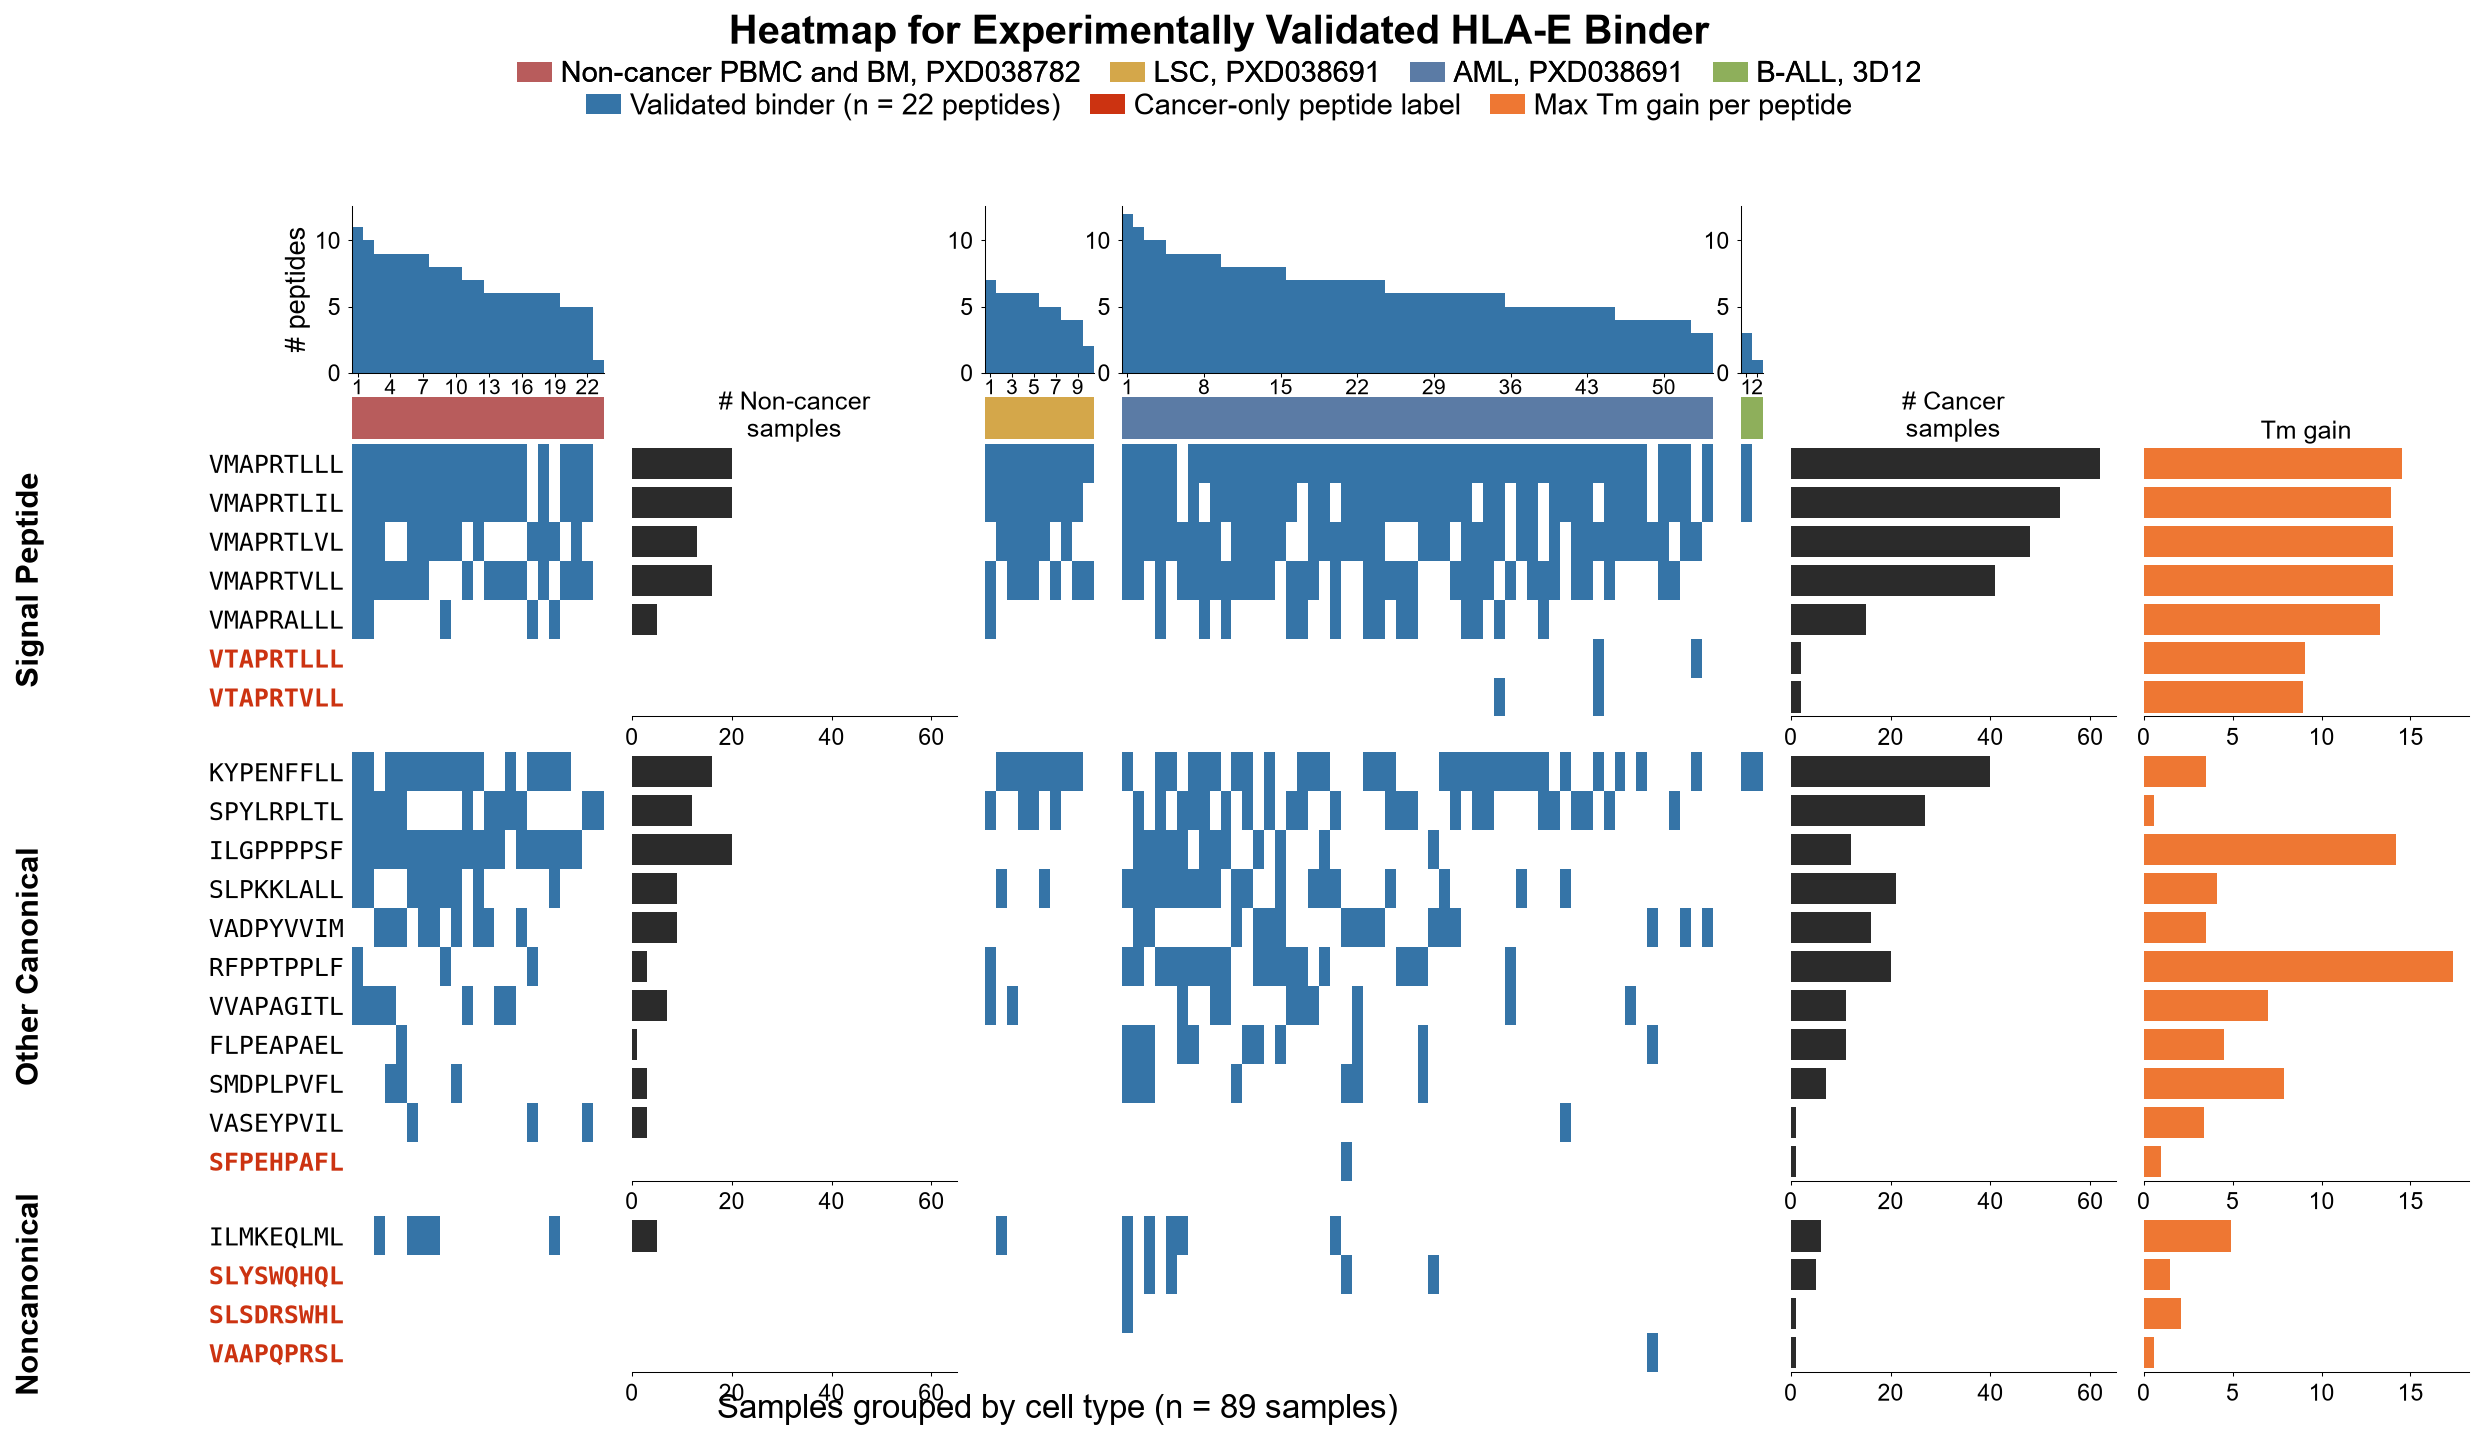

Using sans-serif font: Arial
Peptide groups shown: signal_peptide, other_canonical, noncanonical
Cancer-only peptides: 6
Signal-peptide peptides: 7
Other canonical peptides: 11, Noncanonical peptides: 4
Total samples: 89, Total unique validated peptides: 22


In [13]:
# Order peptides within each display block so every panel shares the same y-axis.
Signal_Peptide_DF = pd.read_csv(os.path.join(data_dir, 'IMGT_HLA', 'hla_prot_signal.csv'))

signal_sequences = Signal_Peptide_DF['signal_peptide'].dropna().astype(str).str.strip().tolist()
signal_peptide_matches = {
    peptide
    for peptide in df_val['peptide'].unique()
    if any(peptide in signal_sequence for signal_sequence in signal_sequences)
}



panel_rank_map = {panel_name: idx for idx, panel_name in enumerate(heatmap_panel_order)}

peptide_group_order = ['signal_peptide', 'other_canonical', 'noncanonical']

peptide_group_labels = {
    'signal_peptide': 'Signal Peptide',
    'other_canonical': 'Other Canonical',
    'noncanonical': 'Noncanonical',
}
peptide_group_rank = {group_name: idx for idx, group_name in enumerate(peptide_group_order)}


pep_freq = df_val.groupby('peptide').size().rename('freq')
pep_info = (
    df_val[['peptide', 'peptide_group']]
    .drop_duplicates(subset=['peptide'])
    .merge(pep_freq, left_on='peptide', right_index=True)
 )
pep_info['group_rank'] = pep_info['peptide_group'].map(peptide_group_rank)
pep_info = pep_info.sort_values(
    ['group_rank', 'freq', 'peptide'],
    ascending=[True, False, True],
).reset_index(drop=True)

group_info = {}
sequence_to_y = {}
group_labels = {}
group_counts = {}
for group_name in peptide_group_order:
    group_df = pep_info[pep_info['peptide_group'].eq(group_name)].reset_index(drop=True)
    group_df['y_idx'] = group_df.index
    group_info[group_name] = group_df
    sequence_to_y[group_name] = dict(zip(group_df['peptide'], group_df['y_idx']))
    group_labels[group_name] = group_df['peptide'].tolist()
    group_counts[group_name] = len(group_df)

active_peptide_groups = [group_name for group_name in peptide_group_order if group_counts[group_name] > 0]
if not active_peptide_groups:
    raise ValueError('No experimentally validated peptides are available for the heatmap.')

# Count unique validated peptides per sample and use that table both for panel ordering
# and for the top-row bar charts.
sample_unique_counts = (
    df_val.groupby(['sample_type', 'Sample'])['peptide']
    .nunique()
    .reset_index(name='unique_peptide_count')
)
sample_unique_counts['panel_rank'] = sample_unique_counts['sample_type'].map(panel_rank_map)
sample_unique_counts = sample_unique_counts.sort_values(
    ['panel_rank', 'unique_peptide_count', 'Sample'],
    ascending=[True, False, True],
).reset_index(drop=True)

panel_samples = {
    panel_name: sample_unique_counts.loc[
        sample_unique_counts['sample_type'].eq(panel_name),
        'Sample',
    ].tolist()
    for panel_name in heatmap_panel_order
}
panel_widths = {panel_name: max(len(samples), 1) for panel_name, samples in panel_samples.items()}

sample_to_local_x = {}
for panel_name, samples in panel_samples.items():
    for local_x, sample_name in enumerate(samples):
        sample_to_local_x[(panel_name, sample_name)] = local_x

df_val['x_local'] = df_val.apply(
    lambda row: sample_to_local_x.get((row['sample_type'], row['Sample']), -1),
    axis=1,
)
df_val = df_val[df_val['x_local'] >= 0].copy()

# Map each peptide to the row index it should occupy inside its display block.
df_val['y'] = np.nan
for group_name in active_peptide_groups:
    group_mask = df_val['peptide_group'].eq(group_name)
    df_val.loc[group_mask, 'y'] = df_val.loc[group_mask, 'peptide'].map(sequence_to_y[group_name])
df_val['y'] = df_val['y'].astype(int)

panel_mats = {group_name: {} for group_name in active_peptide_groups}
sample_unique_counts_by_panel = {}
for panel_name in heatmap_panel_order:
    panel_df = df_val.loc[df_val['sample_type'].eq(panel_name)].copy()
    panel_width = panel_widths[panel_name]

    sample_unique_counts_by_panel[panel_name] = (
        sample_unique_counts.loc[sample_unique_counts['sample_type'].eq(panel_name), ['Sample', 'unique_peptide_count']]
        .set_index('Sample')['unique_peptide_count']
        .reindex(panel_samples[panel_name], fill_value=0)
    )

    for group_name in active_peptide_groups:
        group_height = max(group_counts[group_name], 1)
        mat_panel = np.zeros((group_height, panel_width), dtype=np.uint8)
        panel_group_df = panel_df.loc[panel_df['peptide_group'].eq(group_name)]
        if not panel_group_df.empty:
            mat_panel[panel_group_df['y'].to_numpy(), panel_group_df['x_local'].to_numpy()] = 1
        panel_mats[group_name][panel_name] = mat_panel

# Drop duplicated peptide-sample pairs so the summary bars match the binary heatmap.
group_subsets = {
    group_name: df_val.loc[df_val['peptide_group'].eq(group_name)].drop_duplicates(['peptide', 'Sample']).copy()
    for group_name in active_peptide_groups
}

right_counts = {
    group_name: {
        'Non-cancer samples': group_subsets[group_name].loc[
            group_subsets[group_name]['sample_group'].eq('Non-cancer samples')
        ].groupby('y')['Sample'].nunique(),
        'Cancer samples': group_subsets[group_name].loc[
            group_subsets[group_name]['sample_group'].eq('Cancer samples')
        ].groupby('y')['Sample'].nunique(),
    }
    for group_name in active_peptide_groups
}

tm_gain_by_sequence = df_val.groupby('peptide')['Tm gain'].max()
right_tm_gain = {
    group_name: group_info[group_name]['peptide'].map(tm_gain_by_sequence).fillna(0).to_numpy()
    for group_name in active_peptide_groups
}

n_unique_pep = df_val['peptide'].nunique()
n_unique_samp = df_val['Sample'].nunique()
top_hist_ymax = max(
    [
        int(sample_unique_counts_by_panel[panel_name].max()) if len(sample_unique_counts_by_panel[panel_name]) else 0
        for panel_name in heatmap_panel_order
    ]
    + [1]
 )


active_peptide_groups = [group_name for group_name in peptide_group_order if group_counts[group_name] > 0]
if not active_peptide_groups:
    raise ValueError('No experimentally validated peptides are available for the heatmap.')


# Figure params
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
preferred_fonts = ['Arial', 'Liberation Sans', 'Nimbus Sans', 'DejaVu Sans']
selected_font = next((font for font in preferred_fonts if font in available_fonts), 'DejaVu Sans')

mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': [selected_font, 'DejaVu Sans', 'Liberation Sans'],
    'font.size': 12,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'xtick.major.size': 2,
    'ytick.major.size': 2,
})


cmap_binary = ListedColormap(['#FFFFFF', '#3574A7'])
dot_color = '#3574A7'
tm_gain_color = '#EE7733'
cancer_only_color = '#CC3311'
ball_panel_name = 'B-ALL'
sample_type_colors = {
    non_cancer_sample_type: '#B85C5C',
    'LSC, PXD038691': '#D4A74A',
    'AML, PXD038691': '#5B7BA5',
    ball_panel_name: '#8EAF5B',
}
legend_label_map = {
    non_cancer_sample_type: non_cancer_sample_type,
    'LSC, PXD038691': 'LSC, PXD038691',
    'AML, PXD038691': 'AML, PXD038691',
    ball_panel_name: 'B-ALL, 3D12',
}

row_height = 0.28
group_h_inches = {
    group_name: max(0.6, group_counts[group_name] * row_height)
    for group_name in active_peptide_groups
}
top_marg_inches = 1.2
color_bar_inches = 0.3
gap_inches = 0.15
title_inches = 0.8
legend_space_inches = 0.55 

group_rows = {}
height_ratios = [top_marg_inches, color_bar_inches, 0.05]
current_row = 3
for idx, group_name in enumerate(active_peptide_groups):
    group_rows[group_name] = current_row
    height_ratios.append(group_h_inches[group_name])
    current_row += 1
    if idx < len(active_peptide_groups) - 1:
        height_ratios.append(gap_inches)
        current_row += 1
height_ratios.append(0.05)

fig_height = title_inches + legend_space_inches + sum(height_ratios)
marg_unit = max(panel_widths.values()) * 0.55
width_ratios = [
    panel_widths[non_cancer_sample_type],
    marg_unit,
    panel_widths['LSC, PXD038691'],
    panel_widths['AML, PXD038691'],
    panel_widths[ball_panel_name],
    marg_unit,
    marg_unit,
]

fig = plt.figure(figsize=(17.0, fig_height), dpi=150)
gs = gridspec.GridSpec(
    nrows=len(height_ratios),
    ncols=7,
    height_ratios=height_ratios,
    width_ratios=width_ratios,
    hspace=0.06,
    wspace=0.10,
    left=0.16,
    right=0.99,
    top=1 - (title_inches + legend_space_inches) / fig_height,
    bottom=0.02,
)

ax_top_non_cancer = fig.add_subplot(gs[0, 0])
ax_top_lsc = fig.add_subplot(gs[0, 2])
ax_top_aml = fig.add_subplot(gs[0, 3])
ax_top_ball = fig.add_subplot(gs[0, 4])

ax_ct_non_cancer = fig.add_subplot(gs[1, 0])
ax_ct_lsc = fig.add_subplot(gs[1, 2])
ax_ct_aml = fig.add_subplot(gs[1, 3])
ax_ct_ball = fig.add_subplot(gs[1, 4])

heat_axes = {}
right_non_cancer_axes = {}
right_cancer_axes = {}
tm_axes = {}
for group_name, row_idx in group_rows.items():
    heat_axes[group_name] = {
        non_cancer_sample_type: fig.add_subplot(gs[row_idx, 0]),
        'LSC, PXD038691': fig.add_subplot(gs[row_idx, 2]),
        'AML, PXD038691': fig.add_subplot(gs[row_idx, 3]),
        ball_panel_name: fig.add_subplot(gs[row_idx, 4]),
    }
    right_non_cancer_axes[group_name] = fig.add_subplot(gs[row_idx, 1])
    right_cancer_axes[group_name] = fig.add_subplot(gs[row_idx, 5])
    tm_axes[group_name] = fig.add_subplot(gs[row_idx, 6])

top_axes = {
    non_cancer_sample_type: ax_top_non_cancer,
    'LSC, PXD038691': ax_top_lsc,
    'AML, PXD038691': ax_top_aml,
    ball_panel_name: ax_top_ball,
}
color_bar_axes = {
    non_cancer_sample_type: ax_ct_non_cancer,
    'LSC, PXD038691': ax_ct_lsc,
    'AML, PXD038691': ax_ct_aml,
    ball_panel_name: ax_ct_ball,
}

fig.suptitle('Heatmap for Experimentally Validated HLA-E Binder', fontsize=19, fontweight='bold', y=0.992)

cohort_handles = [
    mpatches.Patch(facecolor=sample_type_colors[label], edgecolor='none', label=legend_label_map[label])
    for label in heatmap_panel_order
]
summary_handles = [
    mpatches.Patch(facecolor=dot_color, edgecolor='none', label=f'Validated binder (n = {n_unique_pep} peptides)'),
    mpatches.Patch(facecolor=cancer_only_color, edgecolor='none', label='Cancer-only peptide label'),
    mpatches.Patch(facecolor=tm_gain_color, edgecolor='none', label='Max Tm gain per peptide'),
]

legend_top = fig.legend(
    handles=cohort_handles,
    loc='upper center',
    frameon=False,
    fontsize=14,
    ncol=len(cohort_handles),
    handlelength=1.2,
    handletextpad=0.3,
    columnspacing=1.0,
    bbox_to_anchor=(0.5, 0.978),
)
fig.add_artist(legend_top)

fig.legend(
    handles=summary_handles,
    loc='upper center',
    frameon=False,
    fontsize=14,
    ncol=len(summary_handles),
    handlelength=1.2,
    handletextpad=0.3,
    columnspacing=1.0,
    bbox_to_anchor=(0.5, 0.955),
)

# The top row is a per-sample bar chart, aligned one-for-one with the heatmap columns.
top_plot_values = {}
for panel_name in heatmap_panel_order:
    top_plot_values[panel_name] = (
        sample_unique_counts_by_panel[panel_name]
        .reindex(panel_samples[panel_name], fill_value=0)
        .to_numpy(dtype=int)
    )

for panel_name, ax_top in top_axes.items():
    top_values = top_plot_values[panel_name]
    panel_width = len(top_values)
    ax_top.bar(np.arange(panel_width), top_values, width=1.0, color=dot_color, edgecolor='none', linewidth=0)
    ax_top.set_xlim(-0.5, max(panel_width - 0.5, 0.5))
    ax_top.set_ylim(0, top_hist_ymax * 1.05)
    ax_top.spines[['top', 'right']].set_visible(False)
    ax_top.tick_params(axis='x', labelsize=10, pad=1)
    ax_top.tick_params(axis='y', labelsize=11)

for panel_name, ax_top in top_axes.items():
    panel_width = len(top_plot_values[panel_name])
    tick_step = max(1, int(np.ceil(max(panel_width, 1) / 8)))
    tick_positions = np.arange(0, max(panel_width, 1), tick_step)
    ax_top.set_xticks(tick_positions)
    ax_top.set_xticklabels((tick_positions + 1).astype(int))

ax_top_non_cancer.set_ylabel('# peptides', fontsize=13, labelpad=2)

color_bar_offset = 0.012
for panel_name, ax_bar in color_bar_axes.items():
    panel_width = panel_widths[panel_name]
    position = ax_bar.get_position()
    ax_bar.set_position([position.x0, position.y0 - color_bar_offset, position.width, position.height])
    ax_bar.bar(np.arange(panel_width), np.ones(panel_width), width=1.0, color=sample_type_colors[panel_name], edgecolor='none', linewidth=0)
    ax_bar.set_xlim(-0.5, panel_width - 0.5)
    ax_bar.set_ylim(0, 1)
    ax_bar.axis('off')

for group_name in active_peptide_groups:
    ax_label = heat_axes[group_name][non_cancer_sample_type]
    ax_label.set_ylabel(
        peptide_group_labels[group_name],
        fontsize=15,
        fontweight='bold',
        rotation=90,
        labelpad=86,
        va='center',
    )

for group_name in active_peptide_groups:
    group_height = max(group_counts[group_name], 1)
    labels = group_labels[group_name]

    for panel_name, ax_heat in heat_axes[group_name].items():
        mat = panel_mats[group_name][panel_name]
        panel_width = panel_widths[panel_name]
        ax_heat.imshow(
            mat,
            aspect='auto',
            cmap=cmap_binary,
            vmin=0,
            vmax=1,
            interpolation='nearest',
            origin='upper',
        )
        ax_heat.set_xlim(-0.5, panel_width - 0.5)
        ax_heat.set_ylim(group_height - 0.5, -0.5)
        ax_heat.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        ax_heat.spines[['top', 'right', 'bottom', 'left']].set_visible(False)

        if panel_name == non_cancer_sample_type:
            ax_heat.set_yticks(np.arange(group_counts[group_name]))
            ax_heat.set_yticklabels(labels, fontsize=12, fontfamily='monospace')
            for tick_label, peptide_label in zip(ax_heat.get_yticklabels(), labels):
                if peptide_label in cancer_only_sequences:
                    tick_label.set_color(cancer_only_color)
                    tick_label.set_fontweight('bold')
            ax_heat.tick_params(axis='y', which='both', left=False, pad=2)
        else:
            ax_heat.tick_params(axis='y', which='both', left=False, labelleft=False)

right_count_max = max(
    *[
        int(right_counts[group_name]['Non-cancer samples'].max() if len(right_counts[group_name]['Non-cancer samples']) else 0)
        for group_name in active_peptide_groups
    ],
    *[
        int(right_counts[group_name]['Cancer samples'].max() if len(right_counts[group_name]['Cancer samples']) else 0)
        for group_name in active_peptide_groups
    ],
    1,
)

for group_name in active_peptide_groups:
    group_height = group_counts[group_name]
    for ax_right, right_data in [
        (right_non_cancer_axes[group_name], right_counts[group_name]['Non-cancer samples']),
        (right_cancer_axes[group_name], right_counts[group_name]['Cancer samples']),
    ]:
        y_vals = np.arange(group_height)
        counts = np.array([right_data.get(y, 0) for y in y_vals])
        ax_right.barh(y_vals, counts, height=0.8, color='#2B2B2B', edgecolor='none', linewidth=0)
        ax_right.set_ylim(max(group_height, 1) - 0.5, -0.5)
        ax_right.set_xlim(0, right_count_max * 1.05)
        ax_right.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax_right.tick_params(axis='x', labelsize=11)
        ax_right.spines[['top', 'right', 'left']].set_visible(False)

first_group = active_peptide_groups[0]
right_non_cancer_axes[first_group].set_title('# Non-cancer\nsamples', fontsize=12, pad=2)
right_cancer_axes[first_group].set_title('# Cancer\nsamples', fontsize=12, pad=2)

tm_gain_max = float(max(
    *[right_tm_gain[group_name].max() if len(right_tm_gain[group_name]) else 0 for group_name in active_peptide_groups],
    1,
) )
for group_name in active_peptide_groups:
    group_height = group_counts[group_name]
    y_vals = np.arange(group_height)
    tm_values = right_tm_gain[group_name]
    ax_tm = tm_axes[group_name]
    ax_tm.barh(y_vals, tm_values, height=0.8, color=tm_gain_color, edgecolor='none', linewidth=0)
    ax_tm.set_ylim(max(group_height, 1) - 0.5, -0.5)
    ax_tm.set_xlim(0, tm_gain_max * 1.05)
    ax_tm.tick_params(axis='y', which='both', left=False, labelleft=False)
    ax_tm.tick_params(axis='x', labelsize=11)
    ax_tm.spines[['top', 'right', 'left']].set_visible(False)

tm_axes[first_group].set_title('Tm gain', fontsize=12, pad=2)

last_group = active_peptide_groups[-1]
left_bbox = heat_axes[last_group][non_cancer_sample_type].get_position()
right_bbox = heat_axes[last_group][ball_panel_name].get_position()
fig.text(
    (left_bbox.x0 + right_bbox.x1) / 2,
    0.015,
    f'Samples grouped by cell type (n = {n_unique_samp} samples)',
    fontsize=16,
    ha='center',
    va='top',
)

fig.savefig(os.path.join(fig_dir, 'aml_pbmc_validated_binder_heatmap_flipped.pdf'), dpi=600, bbox_inches='tight')
fig.savefig(os.path.join(fig_dir, 'aml_pbmc_validated_binder_heatmap_flipped.png'), dpi=600, bbox_inches='tight')
plt.show()

print(f'Using sans-serif font: {selected_font}')
print(f'Peptide groups shown: {", ".join(active_peptide_groups)}')
print(f'Cancer-only peptides: {len(cancer_only_sequences)}')
print(f'Signal-peptide peptides: {group_counts.get("signal_peptide", 0)}')
print(f'Other canonical peptides: {group_counts.get("other_canonical", 0)}, Noncanonical peptides: {group_counts.get("noncanonical", 0)}')
print(f'Total samples: {n_unique_samp}, Total unique validated peptides: {n_unique_pep}')